# Hunt-and-Kill y Búsqueda no Informada

**Curso:** Inteligencia Artificial · **Referencia:** AIMA, capítulo 3  
**Modalidad:** individual · **Duración sugerida:** 3 semanas  
**Producto:** un cuaderno Jupyter con tres implementaciones comparables

## Problema

Se proporciona solamente un generador de laberintos perfectos mediante **Hunt-and-Kill**. A partir del grafo producido, el estudiante deberá diseñar, implementar, verificar y comparar algoritmos de búsqueda no informada para encontrar un camino entre dos celdas.

El proyecto debe realizarse en tres versiones:

1. **Desde cero:** sin bibliotecas de búsqueda ni de grafos.
2. **SimpleAI:** modelando el laberinto como un `SearchProblem`.
3. **AIMA-Python:** modelándolo como una subclase de `Problem`.

> Este cuaderno es deliberadamente incompleto. No contiene implementaciones Python de DFS, BFS, UCS, IDDFS, búsqueda bidireccional ni Lee. El trabajo evaluado consiste en convertir las especificaciones y el pseudocódigo en soluciones propias.

## Resultados de aprendizaje

Al finalizar, el estudiante estará en capacidad de:

- formular un entorno como espacio de estados;
- separar el problema de la estrategia de búsqueda;
- implementar búsqueda en árbol y búsqueda en grafo;
- justificar completitud, optimalidad y complejidad;
- adaptar un mismo problema a dos bibliotecas de IA;
- construir experimentos reproducibles;
- interpretar el algoritmo de Lee como BFS por frentes de onda;
- defender decisiones de diseño y diagnosticar errores sin depender de una solución externa.

## Condiciones y restricciones

- No se permite `networkx` ni funciones externas que ya resuelvan caminos.
- En la versión desde cero no se permite SimpleAI, AIMA-Python ni otra biblioteca de búsqueda.
- Los estados deben ser inmutables y utilizables como claves de diccionario.
- Cada algoritmo debe devolver solución y métricas, no solamente imprimirlas.
- Todas las versiones deben trabajar con el **mismo grafo**, inicio, meta y costos.
- Los resultados deben ser reproducibles mediante semillas.
- No se acepta una imagen como evidencia: deben entregarse estructuras de datos verificables.
- El estudiante debe citar cualquier recurso consultado y conservar una bitácora breve de decisiones.

### Evidencia de autoría y comprensión

La evaluación incluye:

1. historial de al menos seis hitos o commits;
2. una traza manual sobre un laberinto pequeño;
3. defensa oral individual de 5–8 minutos;
4. modificación en vivo de inicio, meta, semilla o costo;
5. explicación de una decisión que produjo un error y cómo se corrigió.

Durante la defensa se podrá solicitar reconstruir una parte pequeña del algoritmo sin consultar el cuaderno.

## 1. Código suministrado: generador Hunt-and-Kill

Este es el único algoritmo completo entregado. El resultado es un diccionario de adyacencia no dirigido:

```text
grafo[celda] = conjunto de celdas conectadas por un corredor
```

Una celda se representa como `(fila, columna)`.

In [1]:
import random


class LaberintoHuntKill:
    """Genera un laberinto perfecto como grafo no dirigido."""

    DIRECCIONES = ((-1, 0), (1, 0), (0, -1), (0, 1))

    def __init__(self, filas=25, columnas=25, semilla=2026):
        self.filas = filas
        self.columnas = columnas
        self.rng = random.Random(semilla)
        self.grafo = {
            (fila, columna): set()
            for fila in range(filas)
            for columna in range(columnas)
        }

    def vecinos_geometricos(self, celda):
        fila, columna = celda
        for df, dc in self.DIRECCIONES:
            vecino = (fila + df, columna + dc)
            if (0 <= vecino[0] < self.filas and
                    0 <= vecino[1] < self.columnas):
                yield vecino

    def conectar(self, origen, destino):
        self.grafo[origen].add(destino)
        self.grafo[destino].add(origen)

    def generar(self):
        no_visitadas = set(self.grafo)
        actual = self.rng.choice(tuple(no_visitadas))
        no_visitadas.remove(actual)

        while no_visitadas:
            # KILL: avanzar aleatoriamente hacia una celda no visitada.
            libres = [
                vecino
                for vecino in self.vecinos_geometricos(actual)
                if vecino in no_visitadas
            ]

            if libres:
                siguiente = self.rng.choice(libres)
                self.conectar(actual, siguiente)
                no_visitadas.remove(siguiente)
                actual = siguiente
                continue

            # HUNT: localizar una celda libre vecina del árbol construido.
            candidatas = []
            for celda in no_visitadas:
                visitados = [
                    vecino
                    for vecino in self.vecinos_geometricos(celda)
                    if vecino not in no_visitadas
                ]
                if visitados:
                    candidatas.append((celda, visitados))

            actual, visitados = self.rng.choice(candidatas)
            vecino = self.rng.choice(visitados)
            self.conectar(actual, vecino)
            no_visitadas.remove(actual)

        return self.grafo

### Actividad 1 — Auditoría del generador

Antes de resolver el laberinto:

1. Explique las fases Hunt y Kill señalando las instrucciones correspondientes.
2. Demuestre que el grafo generado es conexo.
3. Justifique por qué contiene exactamente $|V|-1$ aristas.
4. Explique por qué esas dos propiedades implican que es un árbol.
5. Diseñe pruebas para comprobar:
   - simetría de las adyacencias;
   - ausencia de conexiones diagonales;
   - validez de coordenadas;
   - conectividad;
   - ausencia de ciclos;
   - reproducibilidad con una semilla.

No basta con ejecutar el generador: las propiedades deben verificarse automáticamente.

**Respuesta y pruebas del estudiante:**

### 1. Fases Hunt y Kill

*(referidas a las líneas del código anterior)*

**KILL** — bloque comentado `# KILL: avanzar aleatoriamente...`

Mientras la celda `actual` tenga al menos un vecino geométrico que todavía esté en `no_visitadas`, el algoritmo se comporta como una **caminata aleatoria autoevitante**:

1. Elige uno de esos vecinos libres (`self.rng.choice(libres)`).
2. Lo conecta a `actual` (`self.conectar`).
3. Lo marca como visitado y lo convierte en la nueva celda `actual` (`continue` vuelve al inicio del `while`).

Esta fase construye "pasillos" en línea recta mientras hay territorio virgen alcanzable directamente.

**HUNT** — bloque comentado `# HUNT: localizar una celda libre...`

Se activa solo cuando KILL se atasca, es decir, cuando `actual` no tiene ningún vecino geométrico libre (`libres` queda vacío). Entonces:

1. Se recorren **todas** las celdas aún no visitadas (`for celda in no_visitadas`).
2. Para cada una, se listan sus vecinos que **ya** fueron visitados (`visitados`).
3. Cualquier celda con al menos un vecino visitado es candidata a "resucitar" la caminata.
4. Se elige una candidata al azar, se conecta con uno de sus vecinos ya visitados y se retoma como `actual`.

Esta fase es la que evita que el algoritmo quede atrapado: garantiza que siempre se pueda seguir creciendo el árbol mientras existan celdas sin visitar.



### 2. El grafo generado es conexo

Por construcción, toda arista que se agrega (`self.conectar`) une una celda que **ya** pertenece al árbol parcial (visitada, ergo alcanzable desde la raíz `actual` inicial) con una celda recién retirada de `no_visitadas`:

- En la fase **KILL**, `siguiente` se conecta a `actual` (visitada).
- En la fase **HUNT**, `actual` (la candidata, recién retirada de `no_visitadas`) se conecta con `vecino` (ya visitado).

Es decir, cada celda, en el momento en que deja de estar en `no_visitadas`, queda unida por una arista a una celda que ya era alcanzable desde la primera celda elegida.

> **Por inducción sobre el orden de remoción de `no_visitadas`:**
> la primera celda es trivialmente alcanzable (es la raíz); si las primeras *k* celdas removidas son alcanzables entre sí, la celda *k+1* se conecta a una de ellas, luego también es alcanzable.

Como el bucle `while no_visitadas` solo termina cuando el conjunto queda vacío, todas las celdas terminan siendo alcanzables desde la raíz: **el grafo es conexo**.



### 3. El grafo tiene exactamente |V| − 1 aristas

`self.conectar` es la **única** función que agrega aristas, y se invoca exactamente una vez por iteración exitosa del bucle exterior (una vez en KILL, una vez en HUNT, nunca ambas en la misma vuelta).

Cada llamada a `conectar` remueve exactamente una celda de `no_visitadas` (`no_visitadas.remove(...)`), y nunca se vuelve a insertar una celda ya removida (no hay `add` sobre `no_visitadas`).

Como `no_visitadas` arranca con |V| − 1 elementos (la raíz se remueve antes del bucle) y termina en 0, el bucle ejecuta exactamente |V| − 1 remociones, y por lo tanto exactamente **|V| − 1 llamadas a `conectar`**, es decir, |V| − 1 aristas no dirigidas.



### 4. Conexo + |V| − 1 aristas implica árbol

Es un resultado estándar de teoría de grafos (AIMA, cap. 3, y cualquier texto de grafos):

> Un grafo simple, no dirigido y conexo con *n* vértices es un árbol **si y solo si** tiene exactamente *n* − 1 aristas.

**Intuición:**

- Si tuviera **menos** de *n* − 1 aristas, no podría ser conexo (se necesitan al menos *n* − 1 aristas para conectar *n* vértices).
- Si teniendo *n* vértices conexos tuviera **más** de *n* − 1 aristas, existiría al menos una arista "sobrante" cuya eliminación no desconecta el grafo, lo cual implica que esa arista cerraba un ciclo.

Como el generador produce **exactamente** *n* − 1 aristas (punto 3) y el grafo es conexo (punto 2), no puede contener ciclos: es, por definición, un **árbol** (de ahí que se hable de *"laberinto perfecto"*: un único camino simple entre cualquier par de celdas).

In [2]:
import unittest

class TestGeneradorHuntKill(unittest.TestCase):
 
    def setUp(self):
        self.filas, self.columnas = 8, 8
        self.gen = LaberintoHuntKill(
            filas=self.filas, columnas=self.columnas, semilla=42
        )
        self.grafo = self.gen.generar()
        self.n_celdas = self.filas * self.columnas
 
    # simetría 
    def test_simetria_de_adyacencias(self):
        for celda, vecinos in self.grafo.items():
            for vecino in vecinos:
                self.assertIn(
                    celda, self.grafo[vecino],
                    f"{celda} -> {vecino} no es simétrica",
                )
 
    # sin diagonales 
    def test_sin_conexiones_diagonales(self):
        for (f1, c1), vecinos in self.grafo.items():
            for (f2, c2) in vecinos:
                dist_fila = abs(f1 - f2)
                dist_col = abs(c1 - c2)
                # Debe ser ortogonal: exactamente un paso en una sola dimensión (Manhattan = 1), nunca diagonal.
                self.assertEqual(dist_fila + dist_col, 1)
 
    # coordenadas válidas 
    def test_coordenadas_validas(self):
        for celda in self.grafo:
            fila, columna = celda
            self.assertTrue(0 <= fila < self.filas)
            self.assertTrue(0 <= columna < self.columnas)
        for vecinos in self.grafo.values():
            for (fila, columna) in vecinos:
                self.assertTrue(0 <= fila < self.filas)
                self.assertTrue(0 <= columna < self.columnas)
 
    # conectividad (BFS/DFS propio, sin bibliotecas) 
    def test_conectividad(self):
        raiz = next(iter(self.grafo))
        visitados = {raiz}
        pila = [raiz]
        while pila:
            actual = pila.pop()
            for vecino in self.grafo[actual]:
                if vecino not in visitados:
                    visitados.add(vecino)
                    pila.append(vecino)
        self.assertEqual(len(visitados), self.n_celdas)
 
    # ausencia de ciclos (número de aristas == |V| - 1) 
    def test_ausencia_de_ciclos(self):
        num_aristas = sum(len(v) for v in self.grafo.values()) // 2
        self.assertEqual(num_aristas, self.n_celdas - 1)
 
    def test_ausencia_de_ciclos_por_deteccion_directa(self):

        raiz = next(iter(self.grafo))
        visitados = set()
 
        def dfs(nodo, padre):
            visitados.add(nodo)
            for vecino in self.grafo[nodo]:
                if vecino == padre:
                    continue
                if vecino in visitados:
                    self.fail(f"Ciclo detectado en torno a {vecino}")
                dfs(vecino, nodo)
 
        dfs(raiz, None)
        self.assertEqual(len(visitados), self.n_celdas)
 
    # reproducibilidad 
    def test_reproducibilidad_misma_semilla(self):
        gen_a = LaberintoHuntKill(filas=8, columnas=8, semilla=123)
        gen_b = LaberintoHuntKill(filas=8, columnas=8, semilla=123)
        grafo_a = gen_a.generar()
        grafo_b = gen_b.generar()
        self.assertEqual(grafo_a, grafo_b)
 
    def test_semillas_distintas_pueden_diferir(self):
        gen_a = LaberintoHuntKill(filas=8, columnas=8, semilla=1)
        gen_b = LaberintoHuntKill(filas=8, columnas=8, semilla=2)
        grafo_a = gen_a.generar()
        grafo_b = gen_b.generar()
        # No es una garantía matemática absoluta, pero con 8x8 celda la probabilidad de colisión exacta es despreciable
        self.assertNotEqual(grafo_a, grafo_b)
suite = unittest.TestLoader().loadTestsFromTestCase(TestGeneradorHuntKill)
unittest.TextTestRunner(verbosity=2).run(suite)

test_ausencia_de_ciclos (__main__.TestGeneradorHuntKill.test_ausencia_de_ciclos) ... ok
test_ausencia_de_ciclos_por_deteccion_directa (__main__.TestGeneradorHuntKill.test_ausencia_de_ciclos_por_deteccion_directa) ... ok
test_conectividad (__main__.TestGeneradorHuntKill.test_conectividad) ... ok
test_coordenadas_validas (__main__.TestGeneradorHuntKill.test_coordenadas_validas) ... ok
test_reproducibilidad_misma_semilla (__main__.TestGeneradorHuntKill.test_reproducibilidad_misma_semilla) ... ok
test_semillas_distintas_pueden_diferir (__main__.TestGeneradorHuntKill.test_semillas_distintas_pueden_diferir) ... ok
test_simetria_de_adyacencias (__main__.TestGeneradorHuntKill.test_simetria_de_adyacencias) ... ok
test_sin_conexiones_diagonales (__main__.TestGeneradorHuntKill.test_sin_conexiones_diagonales) ... ok

----------------------------------------------------------------------
Ran 8 tests in 0.046s

OK


<unittest.runner.TextTestResult run=8 errors=0 failures=0>

## 2. Instancia individual

Cada estudiante debe construir una instancia reproducible:

- `semilla = últimos 5 dígitos del código estudiantil`;
- `filas = 20 + último dígito`;
- `columnas = 20 + penúltimo dígito`;
- inicio y meta deben estar en cuadrantes opuestos, pero no necesariamente en las esquinas.

Registre esos valores en una tabla. El docente podrá cambiar cualquiera de ellos durante la defensa.

| Parámetro | Valor |
|---|---|
| Semilla | 95022 |
| Filas | 22 |
| Columnas | 22 |
| Inicio | (21, 9) |
| Meta | (4, 12) |

In [3]:
import random

semilla = 95022
filas = 20 + int(str(semilla)[-1])  
columnas = 20 + int(str(semilla)[-2])

generador = LaberintoHuntKill(filas=filas, columnas=columnas, semilla=semilla)
grafo = generador.generar()

# Elegir inicio y meta en cuadrantes opuestos (no necesariamente esquinas)
def cuadrante_de(celda, filas, columnas):
    fila, columna = celda
    mitad_fila, mitad_columna = filas / 2, columnas / 2
    if fila < mitad_fila and columna < mitad_columna:
        return 1
    if fila < mitad_fila and columna >= mitad_columna:
        return 2
    if fila >= mitad_fila and columna < mitad_columna:
        return 3
    return 4

cuadrante_opuesto = {1: 4, 2: 3, 3: 2, 4: 1}

# RNG independiente pero igual de reproducible (también derivado de la semilla).
rng_posiciones = random.Random(semilla + 1)
cuadrante_inicio = rng_posiciones.choice([1, 2, 3, 4])
cuadrante_meta = cuadrante_opuesto[cuadrante_inicio]

celdas_inicio = [c for c in grafo if cuadrante_de(c, filas, columnas) == cuadrante_inicio]
celdas_meta = [c for c in grafo if cuadrante_de(c, filas, columnas) == cuadrante_meta]

inicio = rng_posiciones.choice(celdas_inicio)
meta = rng_posiciones.choice(celdas_meta)

print("| Parámetro | Valor |")
print("|---|---|")
print(f"| Semilla   | {semilla} |")
print(f"| Filas     | {filas} |")
print(f"| Columnas  | {columnas} |")
print(f"| Inicio    | {inicio} |")
print(f"| Meta      | {meta} |")

| Parámetro | Valor |
|---|---|
| Semilla   | 95022 |
| Filas     | 22 |
| Columnas  | 22 |
| Inicio    | (21, 9) |
| Meta      | (4, 12) |


## 3. Formulación formal del problema

Defina rigurosamente:

| Componente | Especificación por completar |
|---|---|
| Conjunto de estados       | Todas las celdas (fila, columna) con 0 <= fila < filas, 0 <= columna < columnas. Un estado es una tupla inmutable (fila, columna); coincide con los vértices del grafo generado por LaberintoHuntKill. |
| Estado inicial            | La celda `inicio` fijada en la instancia individual (sección 2).              |
| Acciones aplicables       | Dado un estado s, Acciones(s) = { mover_a(v) : v ∈ grafo[s] }. Es decir, moverse a cualquier celda directamente conectada a s por un corredor. El conjunto depende solo de las adyacencias del grafo, no de la posición geométrica de s en la cuadrícula. |
| Modelo de transición      | Resultado(s, mover_a(v)) = v, para v ∈ grafo[s]. Determinista: cada acción produce exactamente un sucesor. |
| Prueba de objetivo        | EsMeta(s)  ⇔  s = meta.                                                       |
| Costo de paso             | En la versión base (laberinto perfecto, sin ponderar): costo(s, a, s') = 1 para toda transición válida. En la extensión de la sección 9.B, costo(s, a, s') = peso(arista(s, s')) > 0, definido explícitamente por arista (ver esa sección). |
| Costo de una solución     | Suma de los costos de paso a lo largo del camino inicio → meta: g(meta) = Σ costo(sᵢ, aᵢ, sᵢ₊₁) para i = 0 .. n-1, donde s₀ = inicio y sₙ = meta. ||

Además:

1. diferencie **estado**, **nodo de búsqueda** y **celda dibujada**;
2. indique cuándo dos nodos distintos pueden contener el mismo estado;
3. explique por qué debe usarse búsqueda en grafo;
4. establezca invariantes que deben cumplirse durante una búsqueda.

## Respuesta a preguntas adicionales

### 1. Estado vs. nodo de búsqueda vs. celda dibujada

- **Estado:** la tupla `(fila, columna)` tal como aparece en el grafo. Es la unidad **matemática** del problema; es inmutable y hasheable.

- **Nodo de búsqueda:** estructura auxiliar utilizada por el algoritmo que **envuelve un estado** y añade metadatos de la búsqueda:
  - Padre.
  - Acción que lo generó.
  - Costo acumulado `g`.
  - Profundidad.

  Varios nodos de búsqueda distintos pueden envolver el mismo estado (ver pregunta 2).

- **Celda dibujada:** representación gráfica o visual del estado, por ejemplo, un píxel o un rectángulo coloreado en una figura de `matplotlib`. Se utiliza únicamente para mostrar el resultado a una persona.

  La celda dibujada **no participa en el algoritmo** y no debe utilizarse como fuente de verdad para ninguna prueba automática. De ahí la restricción de la sección **«Condiciones y restricciones»**: *«no se acepta una imagen como evidencia»*.

---

### 2. ¿Cuándo dos nodos distintos contienen el mismo estado?

Esto ocurre cuando el grafo **no es un árbol**, es decir, cuando existe más de un camino posible entre el estado inicial y un mismo estado.

Por ejemplo, esto puede ocurrir después de introducir ciclos en la sección **9.A**. En ese caso:

1. Dos ramas distintas de la búsqueda pueden llegar al mismo estado.
2. Cada rama puede haber seguido un camino diferente.
3. Por lo tanto, los caminos pueden tener costos acumulados `g` diferentes.
4. Se generan dos nodos de búsqueda distintos, con diferente padre y/o diferente `g`, que envuelven el mismo estado.

En el **laberinto perfecto original (árbol)** esto no puede ocurrir en una búsqueda en árbol sin repetición, porque solo existe un camino simple entre cualquier par de celdas.

Aun así, el mismo estado puede aparecer **transitoriamente en la frontera** si es generado como sucesor de dos nodos distintos antes de ser expandido.

---

### 3. ¿Por qué debe usarse búsqueda en grafo?

La **búsqueda en árbol**, al no tener control de repetidos, vuelve a expandir estados ya visitados cada vez que estos reaparecen como sucesores.

Esto presenta dos problemas:

- **En el laberinto base:** es innecesario, porque el grafo es un árbol y cualquier repetición simplemente representaría volver por donde se vino.
- **Cuando existen ciclos (sección 9.A):** el problema puede volverse explosivo, ya que el algoritmo podría recorrer el mismo ciclo indefinidamente y no terminar en un tiempo razonable.

La **búsqueda en grafo**, mediante un conjunto de estados `alcanzados` o `visitados`:

- Evita procesar repetidamente los mismos estados.
- Evita trabajo redundante.
- Garantiza la terminación en los casos correspondientes, evitando recorridos infinitos por ciclos.

La contrapartida es un **mayor consumo de memoria**, ya que es necesario almacenar los estados que ya han sido vistos.

---

### 4. Invariantes que deben cumplirse durante una búsqueda

Durante la ejecución del algoritmo deben mantenerse, como mínimo, los siguientes invariantes:

- **Alcanzabilidad:** todo estado que aparece en la frontera debe ser alcanzable desde el estado inicial mediante una secuencia válida de acciones.

- **Consistencia del costo:** `g(nodo)` debe ser exactamente la suma de los costos de los pasos a lo largo del camino registrado mediante los punteros a los padres. No debe ser un valor inventado o estar desincronizado del camino que puede reconstruirse.

- **Estados resueltos:** un estado no debe estar simultáneamente marcado como **definitivamente resuelto** (por ejemplo, expandido con costo óptimo en UCS) y seguir generando reemplazos con un costo peor.

- **Contador de expansiones:** `expandidos` solo debe incrementarse cuando un nodo se retira de la frontera **y se generan sus sucesores**, de acuerdo con el contrato del punto 4. No debe incrementarse dos veces para el mismo nodo.

- **Reconstrucción del camino:** cuando `encontrado = True`, el camino reconstruido debe comenzar en `inicio` y terminar en `meta`. Cuando `encontrado = False`, el camino debe ser vacío.


## 4. Contrato común de las tres versiones

Todos los algoritmos deben entregar un registro equivalente a:

```text
ResultadoBusqueda
    encontrado: booleano
    camino: secuencia de estados
    acciones: secuencia de acciones
    costo: número
    profundidad: entero
    expandidos: entero
    generados: entero
    repetidos_descartados: entero
    frontera_maxima: entero
    tiempo_ms: número
```

### Convenciones obligatorias

- Un estado se cuenta como **expandido** al retirarlo de la frontera y generar sus sucesores.
- Un nodo meta retirado de la frontera no se cuenta como expandido si no se generan sucesores.
- **Generado** significa nodo sucesor construido, aunque luego sea descartado.
- La política para estados repetidos debe documentarse.
- El camino debe incluir inicio y meta.
- Si no hay solución, `camino` debe ser vacío y `encontrado` falso.

Estas convenciones son necesarias para comparar implementaciones de manera justa.

## 5. Pseudocódigo base: búsqueda en grafo

El siguiente esquema no especifica la estructura de la frontera ni resuelve el manejo de costos. Debe especializarlo y justificar cada decisión.

```text
BUSQUEDA-GRAFO(problema, frontera):
    nodo_inicial ← crear_nodo(problema.estado_inicial)
    insertar(frente, nodo_inicial)
    alcanzados ← estructura apropiada

    mientras frontera no esté vacía:
        nodo ← extraer_segun_politica(frontera)

        si ES_META(nodo.estado):
            devolver RECONSTRUIR(nodo)

        si nodo debe expandirse:
            para cada acción aplicable:
                hijo ← construir sucesor
                decidir si insertar, reemplazar o descartar hijo

        actualizar métricas

    devolver FRACASO
```

### Preguntas de diseño

1. ¿Cuándo debe marcarse un estado: al generarlo o al expandirlo?
2. ¿La respuesta cambia entre BFS, DFS y UCS?
3. ¿Qué información mínima debe almacenar cada nodo?
4. ¿Cómo se reconstruye el camino sin copiar listas completas en cada nodo?
5. ¿Cómo se resuelve un camino más barato hacia un estado ya descubierto?

### 1. ¿Cuándo debe marcarse un estado, al generarlo o al expandirlo?

No hay una única respuesta correcta para todos los algoritmos:

- **Marcar al GENERAR:** evita que el mismo estado entre múltiples veces a la frontera. Esto produce una frontera más pequeña y requiere menos memoria.
- **Marcar al EXPANDIR:** es más simple de implementar, pero permite que copias duplicadas del mismo estado convivan temporalmente en la frontera antes de ser descartadas.

### 2. ¿La respuesta cambia entre BFS, DFS y UCS?

Sí:

- **BFS:** se marca al **GENERAR**. Como BFS expande por niveles y la primera vez que se alcanza un estado es siempre por el camino más corto (costo unitario), no tiene sentido permitir que ese estado vuelva a entrar a la cola. Marcarlo al generarlo evita crecimiento innecesario de la frontera sin sacrificar optimalidad.

- **DFS:** en esta implementación se marca al **EXPANDIR** (`alcanzados` se llena cuando el nodo se retira y se generan sucesores), porque a DFS no le preocupa el orden de llegada sino explorar en profundidad. Marcar al expandir es la variante más simple y es la que corresponde a "búsqueda en grafo" clásica de AIMA.

- **UCS:** **NO** basta con una marca binaria "visto/no visto". Un estado puede reaparecer con un costo `g` estrictamente menor al mejor conocido y, en ese caso, **SÍ debe reinsertarse con el costo actualizado**.

  Aquí se usa una marca condicional: se mantiene `mejor_costo[estado]` y solo se descarta un sucesor si su nuevo costo **NO mejora** `mejor_costo[estado]`.

### 3. ¿Qué información mínima debe almacenar cada nodo?

Cada nodo debe almacenar:

- **Estado**
- **Referencia al nodo padre** (no la lista completa de ancestros)
- **Acción que lo generó**
- **Costo acumulado `g`**
- **Profundidad**, opcionalmente

La profundidad se puede derivar de `padre.profundidad + 1`, pero almacenarla como atributo permite evitar recalcularla.

Ver la clase `Nodo` abajo.

### 4. ¿Cómo se reconstruye el camino sin copiar listas completas en cada nodo?

Cada nodo solo guarda un puntero al **nodo padre** y la **acción que lo generó**.

Para reconstruir el camino:

1. Se comienza desde el nodo objetivo.
2. Se sigue la referencia `padre` hacia atrás hasta llegar al nodo inicial.
3. Se almacenan las acciones encontradas.
4. Finalmente, se invierte la lista de acciones para obtener el camino desde el estado inicial hasta el objetivo.

De esta forma, no es necesario copiar la lista completa de ancestros en cada nodo.


# Versión 1 — Implementación desde cero

No puede utilizar bibliotecas de búsqueda o grafos. Se permiten únicamente estructuras estándar como listas, diccionarios, conjuntos, `deque` y colas de prioridad.

Debe implementar:

1. DFS iterativa;
2. BFS;
3. búsqueda de costo uniforme;
4. búsqueda limitada en profundidad;
5. profundización iterativa;
6. búsqueda bidireccional;
7. Lee o expansión por frente de onda.

La versión debe separar, como mínimo:

- representación del problema;
- representación de nodos;
- política de frontera;
- control de repetidos;
- reconstrucción del camino;
- recolección de métricas.

In [4]:
from collections import deque
from dataclasses import dataclass
from typing import Dict, List, Optional, Tuple
import time
import itertools
import heapq
from dataclasses import dataclass  
from typing import Dict, List, Tuple 
 
Celda = Tuple[int, int]
Grafo = Dict[Celda, set]
 
 
@dataclass
class ResultadoBusqueda:
    """
    ("Contrato comun de las tres versiones"): encontrado, camino, acciones, costo, profundidad, expandidos, generados,
    repetidos_descartados, frontera_maxima, tiempo_ms.
    """
    encontrado: bool = False
    camino: List[Celda] = None
    acciones: List[Celda] = None
    costo: float = 0
    profundidad: int = 0
    expandidos: int = 0
    generados: int = 0
    repetidos_descartados: int = 0
    frontera_maxima: int = 0
    tiempo_ms: float = 0.0
 
    def __post_init__(self):
        # Evita el error clasico de usar listas mutables como valor por defecto en un dataclass (serian compartidas entre instancias).
        if self.camino is None:
            self.camino = []
        if self.acciones is None:
            self.acciones = []

class ProblemaLaberinto:
    """
    Traduce la formulación formal del punto 3 en código ejecutable.
    No depende de ninguna biblioteca de grafos: usa directamente el
    diccionario de adyacencia producido por LaberintoHuntKill.
    """
 
    def __init__(self, grafo: Grafo, inicio: Celda, meta: Celda,
                 costos: Optional[Dict[frozenset, float]] = None):
        self.grafo = grafo
        self.inicio = inicio
        self.meta = meta
        # costos: mapa {frozenset({a, b}): costo}. Si es None, todo paso cuesta 1 (laberinto perfecto sin ponderar).
        self.costos = costos
    def acciones(self, estado: Celda) -> List[Celda]:
        """Orden determinista (ordenado) para reproducibilidad exacta
        entre ejecuciones y entre algoritmos."""
        return sorted(self.grafo[estado])
    def resultado(self, estado: Celda, accion: Celda) -> Celda:
        # La acción "mover_a(v)" se representa directamente como el estado destino v; el modelo de transición es la identidad sobre la acción.
        return accion
    def es_meta(self, estado: Celda) -> bool:
        return estado == self.meta
    def costo_paso(self, estado: Celda, accion: Celda, estado2: Celda) -> float:
        if self.costos is None:
            return 1
        return self.costos.get(frozenset((estado, estado2)), 1)
 
 
@dataclass
class Nodo:
    # Información mínima de un nodo de búsqueda
    estado: Celda
    padre: Optional["Nodo"]
    accion: Optional[Celda]
    g: float
    profundidad: int
 
 
def reconstruir_camino(nodo: Nodo) -> Tuple[List[Celda], List[Celda]]:
    # Reconstruye camino y acciones siguiendo punteros a padre, sin copiar listas en cada nodo.
    camino: List[Celda] = []
    acciones: List[Celda] = []
    actual: Optional[Nodo] = nodo
    while actual is not None:
        camino.append(actual.estado)
        if actual.accion is not None:
            acciones.append(actual.accion)
        actual = actual.padre
    camino.reverse()
    acciones.reverse()
    return camino, acciones
 
 
class FronteraLIFO:
    #Política de frontera para DFS: pila (Last In, First Out).
 
    def __init__(self):
        self._datos: List[Nodo] = []
    def insertar(self, nodo: Nodo) -> None:
        self._datos.append(nodo)
    def extraer(self) -> Nodo:
        return self._datos.pop()
    def vacia(self) -> bool:
        return not self._datos
    def __len__(self) -> int:
        return len(self._datos)
 
 
class FronteraFIFO:
    # Política de frontera para BFS: cola (First In, First Out).
    def __init__(self):
        self._datos: deque = deque()
    def insertar(self, nodo: Nodo) -> None:
        self._datos.append(nodo)
    def extraer(self) -> Nodo:
        return self._datos.popleft()
    def vacia(self) -> bool:
        return not self._datos
    def __len__(self) -> int:
        return len(self._datos)

## 6. Pseudocódigo que debe traducirse

### DFS y BFS

```text
inicializar frontera con el nodo inicial
inicializar alcanzados

mientras haya nodos:
    extraer según disciplina LIFO o FIFO
    comprobar objetivo
    expandir
    insertar estados nuevos
```

La diferencia no debe quedar dispersa por todo el programa. Diseñe una abstracción que permita cambiar la política de frontera.

### Costo uniforme

```text
frontera ← cola de prioridad ordenada por g(n)
mejor_costo[inicial] ← 0

mientras frontera no esté vacía:
    extraer nodo con menor g
    ignorar entradas obsoletas
    comprobar objetivo
    para cada sucesor:
        nuevo_costo ← g(nodo) + costo_de_paso
        si mejora el costo conocido:
            actualizar costo, padre y frontera
```

### Profundización iterativa

```text
para límite = 0, 1, 2, ...:
    resultado ← BUSQUEDA-LIMITADA(problema, límite)
    si resultado es solución: devolverlo
    si resultado es fracaso definitivo: terminar
```

Debe distinguir **corte** de **fracaso**.

### Bidireccional

```text
crear una frontera desde inicio y otra desde meta
expandir de forma equilibrada
detectar intersección entre regiones alcanzadas
unir los dos caminos respetando su orientación
```

No se acepta ejecutar dos búsquedas completas y comparar al final.

In [5]:
#Busqueda DFS y BFS
def _busqueda_dfs_o_bfs(problema: ProblemaLaberinto, tipo: str) -> ResultadoBusqueda:
    """
    Una sola función para DFS y BFS: la diferencia entre ambos NO está dispersa por el programa (como pide el enunciado), está
    ÚNICAMENTE en qué clase de frontera se inyecta.
 
    Política de marcado:
        - BFS marca al GENERAR (evita duplicados en la cola).
        - DFS marca al EXPANDIR (variante clásica de grafo-DFS).
    """
    assert tipo in ("DFS", "BFS")
    inicio_t = time.perf_counter()
 
    frontera = FronteraLIFO() if tipo == "DFS" else FronteraFIFO()
    nodo_inicial = Nodo(estado=problema.inicio, padre=None, accion=None, g=0, profundidad=0)
    frontera.insertar(nodo_inicial)
 
    alcanzados = {problema.inicio}  # para BFS: marca de "ya en frontera o expandido"
    expandidos_marca = set()        # para DFS: marca de "ya expandido"
 
    expandidos = generados = repetidos_descartados = 0
    frontera_maxima = len(frontera)
 
    while not frontera.vacia():
        frontera_maxima = max(frontera_maxima, len(frontera))
        nodo = frontera.extraer()
        if problema.es_meta(nodo.estado):
            camino, acciones = reconstruir_camino(nodo)
            return ResultadoBusqueda(
                encontrado=True, camino=camino, acciones=acciones,
                costo=nodo.g, profundidad=nodo.profundidad,
                expandidos=expandidos, generados=generados,
                repetidos_descartados=repetidos_descartados,
                frontera_maxima=frontera_maxima,
                tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
            )
        if tipo == "DFS":
            if nodo.estado in expandidos_marca:
                continue
            expandidos_marca.add(nodo.estado)
 
        expandidos += 1
        for accion in problema.acciones(nodo.estado):
            sucesor = problema.resultado(nodo.estado, accion)
            generados += 1
 
            if tipo == "BFS":
                if sucesor in alcanzados:
                    repetidos_descartados += 1
                    continue
                alcanzados.add(sucesor)
            else:  # DFS
                if sucesor in expandidos_marca:
                    repetidos_descartados += 1
                    continue
 
            hijo = Nodo(
                estado=sucesor, padre=nodo, accion=accion,
                g=nodo.g + problema.costo_paso(nodo.estado, accion, sucesor),
                profundidad=nodo.profundidad + 1,
            )
            frontera.insertar(hijo)
 
    return ResultadoBusqueda(
        encontrado=False, expandidos=expandidos, generados=generados,
        repetidos_descartados=repetidos_descartados,
        frontera_maxima=frontera_maxima,
        tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
    )
 
def busqueda_dfs(problema: ProblemaLaberinto) -> ResultadoBusqueda:
    return _busqueda_dfs_o_bfs(problema, "DFS")
def busqueda_bfs(problema: ProblemaLaberinto) -> ResultadoBusqueda:
    return _busqueda_dfs_o_bfs(problema, "BFS")

In [6]:
#Busqueda de costo uniforme
def busqueda_costo_uniforme(problema: ProblemaLaberinto) -> ResultadoBusqueda:
    """
    UCS con cola de prioridad (heapq) y descarte perezoso de entradas obsoletas (punto 5, pregunta 5). `contador` desempata entradas con
    el mismo costo respetando el orden de inserción (heapq no compara Nodo directamente).
    """
    inicio_t = time.perf_counter()
    contador = itertools.count()
 
    nodo_inicial = Nodo(estado=problema.inicio, padre=None, accion=None, g=0, profundidad=0)
    frontera: List[Tuple[float, int, Nodo]] = [(0, next(contador), nodo_inicial)]
    mejor_costo: Dict[Celda, float] = {problema.inicio: 0}
 
    expandidos = generados = repetidos_descartados = 0
    frontera_maxima = len(frontera)
 
    while frontera:
        frontera_maxima = max(frontera_maxima, len(frontera))
        costo_extraido, _, nodo = heapq.heappop(frontera)
        # Ignorar entradas obsoletas (ya superadas por un costo mejor).
        if costo_extraido > mejor_costo.get(nodo.estado, float("inf")):
            continue
        if problema.es_meta(nodo.estado):
            camino, acciones = reconstruir_camino(nodo)
            return ResultadoBusqueda(
                encontrado=True, camino=camino, acciones=acciones,
                costo=nodo.g, profundidad=nodo.profundidad,
                expandidos=expandidos, generados=generados,
                repetidos_descartados=repetidos_descartados,
                frontera_maxima=frontera_maxima,
                tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
            )
        expandidos += 1
        for accion in problema.acciones(nodo.estado):
            sucesor = problema.resultado(nodo.estado, accion)
            nuevo_costo = nodo.g + problema.costo_paso(nodo.estado, accion, sucesor)
            generados += 1
 
            if nuevo_costo < mejor_costo.get(sucesor, float("inf")):
                mejor_costo[sucesor] = nuevo_costo
                hijo = Nodo(
                    estado=sucesor, padre=nodo, accion=accion,
                    g=nuevo_costo, profundidad=nodo.profundidad + 1,
                )
                heapq.heappush(frontera, (nuevo_costo, next(contador), hijo))
            else:
                repetidos_descartados += 1
 
    return ResultadoBusqueda(
        encontrado=False, expandidos=expandidos, generados=generados,
        repetidos_descartados=repetidos_descartados,
        frontera_maxima=frontera_maxima,
        tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
    )

In [7]:
#Busqueda de profundidad iterativa
def busqueda_profundizacion_iterativa(
    problema: ProblemaLaberinto, limite_maximo: Optional[int] = None
) -> ResultadoBusqueda:
    """
    IDDFS: llama a búsqueda limitada con límites 0, 1, 2, ... Se detiene al encontrar solución, o cuando una vuelta termina SIN
    corte (fracaso definitivo: ya no queda nada más profundo por explorar). `limite_maximo` es una cota de seguridad opcional para
    evitar recursión/ bucle infinito si algo del modelo está mal formulado.
    """
    if limite_maximo is None:
        limite_maximo = len(problema.grafo)  # cota superior segura
 
    expandidos_totales = generados_totales = repetidos_totales = 0
    frontera_maxima_global = 0
    inicio_t = time.perf_counter()
 
    for limite in range(limite_maximo + 1):
        resultado, hubo_corte = busqueda_limitada_profundidad(problema, limite)
        expandidos_totales += resultado.expandidos
        generados_totales += resultado.generados
        repetidos_totales += resultado.repetidos_descartados
        frontera_maxima_global = max(frontera_maxima_global, resultado.frontera_maxima)
        if resultado.encontrado:
            resultado.expandidos = expandidos_totales
            resultado.generados = generados_totales
            resultado.repetidos_descartados = repetidos_totales
            resultado.frontera_maxima = frontera_maxima_global
            resultado.tiempo_ms = (time.perf_counter() - inicio_t) * 1000
            return resultado
        if not hubo_corte:
            # Fracaso definitivo: en la última vuelta no hubo ningun corte por límite, es decir, se agotó el espacio real.
            break
 
    return ResultadoBusqueda(
        encontrado=False, expandidos=expandidos_totales,
        generados=generados_totales,
        repetidos_descartados=repetidos_totales,
        frontera_maxima=frontera_maxima_global,
        tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
    )

In [8]:
#Busqueda bidireccional
def busqueda_bidireccional(problema: ProblemaLaberinto) -> ResultadoBusqueda:
    """
    BFS simultánea desde `inicio` y desde `meta`, expandiendo de forma equilibrada (una capa de cada lado por turno) y deteniéndose en
    cuanto las dos regiones alcanzadas se intersectan (no se ejecutan dos búsquedas completas por separado). El grafo es no dirigido,
    así que "ir hacia atrás" desde la meta usa las mismas adyacencias.
    """
    inicio_t = time.perf_counter()
 
    if problema.inicio == problema.meta:
        return ResultadoBusqueda(
            encontrado=True, camino=[problema.inicio], acciones=[],
            costo=0, profundidad=0, expandidos=0, generados=0,
            repetidos_descartados=0, frontera_maxima=1,
            tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
        )
 
    nodo_ini = Nodo(estado=problema.inicio, padre=None, accion=None, g=0, profundidad=0)
    nodo_meta = Nodo(estado=problema.meta, padre=None, accion=None, g=0, profundidad=0)
 
    frontera_ini = deque([nodo_ini])
    frontera_meta = deque([nodo_meta])
    alcanzados_ini: Dict[Celda, Nodo] = {problema.inicio: nodo_ini}
    alcanzados_meta: Dict[Celda, Nodo] = {problema.meta: nodo_meta}
 
    expandidos = generados = repetidos_descartados = 0
    frontera_maxima = len(frontera_ini) + len(frontera_meta)
 
    def _expandir_una_capa(frontera, alcanzados_propios, alcanzados_ajenos):
        nonlocal expandidos, generados, repetidos_descartados
        for _ in range(len(frontera)):
            nodo = frontera.popleft()
            expandidos += 1
            for accion in problema.acciones(nodo.estado):
                sucesor = problema.resultado(nodo.estado, accion)
                generados += 1
                if sucesor in alcanzados_propios:
                    repetidos_descartados += 1
                    continue
                hijo = Nodo(
                    estado=sucesor, padre=nodo, accion=accion,
                    g=nodo.g + problema.costo_paso(nodo.estado, accion, sucesor),
                    profundidad=nodo.profundidad + 1,
                )
                alcanzados_propios[sucesor] = hijo
                frontera.append(hijo)
                if sucesor in alcanzados_ajenos:
                    return sucesor  # punto de encuentro detectado
        return None
 
    punto_encuentro = None
    while frontera_ini and frontera_meta and punto_encuentro is None:
        frontera_maxima = max(frontera_maxima, len(frontera_ini) + len(frontera_meta))
        punto_encuentro = _expandir_una_capa(frontera_ini, alcanzados_ini, alcanzados_meta)
        if punto_encuentro is None:
            frontera_maxima = max(frontera_maxima, len(frontera_ini) + len(frontera_meta))
            punto_encuentro = _expandir_una_capa(frontera_meta, alcanzados_meta, alcanzados_ini)
 
    if punto_encuentro is None:
        return ResultadoBusqueda(
            encontrado=False, expandidos=expandidos, generados=generados,
            repetidos_descartados=repetidos_descartados,
            frontera_maxima=frontera_maxima,
            tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
        )
 
    # Unir los dos caminos respetando su orientación: el lado "meta" se reconstruye y se invierte antes de pegarlo al lado "inicio".
    camino_desde_inicio, acciones_desde_inicio = reconstruir_camino(
        alcanzados_ini[punto_encuentro]
    )
    camino_hacia_meta, acciones_hacia_meta_invertidas = reconstruir_camino(
        alcanzados_meta[punto_encuentro]
    )
    camino_hacia_meta.reverse()  # ahora va de punto_encuentro hacia meta

    acciones_encuentro_a_meta = camino_hacia_meta[1:]
 
    camino_completo = camino_desde_inicio + camino_hacia_meta[1:]
    acciones_completas = acciones_desde_inicio + acciones_encuentro_a_meta
 
    costo_total = sum(
        problema.costo_paso(camino_completo[i], camino_completo[i + 1], camino_completo[i + 1])
        for i in range(len(camino_completo) - 1)
    )
 
    return ResultadoBusqueda(
        encontrado=True, camino=camino_completo, acciones=acciones_completas,
        costo=costo_total, profundidad=len(camino_completo) - 1,
        expandidos=expandidos, generados=generados,
        repetidos_descartados=repetidos_descartados,
        frontera_maxima=frontera_maxima,
        tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
    )

In [9]:
def busqueda_limitada_profundidad(
    problema: ProblemaLaberinto, limite: int
) -> Tuple[ResultadoBusqueda, bool]:
    """
    DFS con límite de profundidad. Devuelve (resultado, hubo_corte). `hubo_corte=True` significa "no se encontró solución DENTRO del
    límite, pero podría existir más profundo" (CORTE, distinto de FRACASO definitivo, que sería `hubo_corte=False` con
    `encontrado=False`: en ese caso se agotó todo el espacio alcanzable sin necesidad de cortar por profundidad).
    """
    inicio_t = time.perf_counter()
    expandidos = generados = repetidos_descartados = 0
    frontera_maxima = 0
    hubo_corte = False
 
    """
    Pila explícita con marca de expansión SOLO en la rama actual(no global), porque en DFS limitado por profundidad conviene
    permitir revisitar un estado por otra rama si el límite lo permite; para simplificar y mantener el contrato de "búsqueda en
    grafo" se usa aquí una marca por profundidad mínima alcanzada.
    """
    mejor_profundidad_vista: Dict[Celda, int] = {}

    nodo_inicial = Nodo(estado=problema.inicio, padre=None, accion=None, g=0, profundidad=0)
    pila = [nodo_inicial]
    frontera_maxima = len(pila)
 
    while pila:
        frontera_maxima = max(frontera_maxima, len(pila))
        nodo = pila.pop()
        if problema.es_meta(nodo.estado):
            camino, acciones = reconstruir_camino(nodo)
            resultado = ResultadoBusqueda(
                encontrado=True, camino=camino, acciones=acciones,
                costo=nodo.g, profundidad=nodo.profundidad,
                expandidos=expandidos, generados=generados,
                repetidos_descartados=repetidos_descartados,
                frontera_maxima=frontera_maxima,
                tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
            )
            return resultado, False
        if nodo.profundidad >= limite:
            hubo_corte = True
            continue
        if (nodo.estado in mejor_profundidad_vista and
                mejor_profundidad_vista[nodo.estado] <= nodo.profundidad):
            repetidos_descartados += 1
            continue
        mejor_profundidad_vista[nodo.estado] = nodo.profundidad
        expandidos += 1
        for accion in problema.acciones(nodo.estado):
            sucesor = problema.resultado(nodo.estado, accion)
            generados += 1
            hijo = Nodo(
                estado=sucesor, padre=nodo, accion=accion,
                g=nodo.g + problema.costo_paso(nodo.estado, accion, sucesor),
                profundidad=nodo.profundidad + 1,
            )
            pila.append(hijo)
 
    resultado = ResultadoBusqueda(
        encontrado=False, expandidos=expandidos, generados=generados,
        repetidos_descartados=repetidos_descartados,
        frontera_maxima=frontera_maxima,
        tiempo_ms=(time.perf_counter() - inicio_t) * 1000,
    )
    return resultado, hubo_corte

## 7. Lee: propagación de un frente luminoso

No se modela un único rayo que rebota. Se modela una onda que avanza simultáneamente por todos los corredores accesibles.

```text
LEE(grafo, inicio, meta):
    etiqueta[inicio] ← 0
    frente_actual ← {inicio}

    mientras frente_actual no esté vacío y meta no tenga etiqueta:
        frente_siguiente ← vacío
        para cada celda del frente_actual:
            para cada vecino transitable sin etiqueta:
                etiqueta[vecino] ← etiqueta[celda] + 1
                registrar procedencia o dirección
                agregar vecino al frente_siguiente
        frente_actual ← frente_siguiente

    si meta no tiene etiqueta: devolver fracaso
    reconstruir desde meta siguiendo etiquetas decrecientes
```

### Requisitos adicionales

- Dibuje al menos ocho instantes del frente de onda.
- Use una escala de color que represente el tiempo de llegada.
- Compruebe que la etiqueta de la meta coincide con la profundidad de BFS.
- Explique formalmente por qué Lee es BFS en un grafo no ponderado.
- Analice qué deja de funcionar cuando los costos no son unitarios.

Lee -> encontrado=True  etiqueta_meta=48  pasos=48  tiempo_ms=0.648
Verificación OK: etiqueta_meta(Lee) == profundidad(BFS) = 48


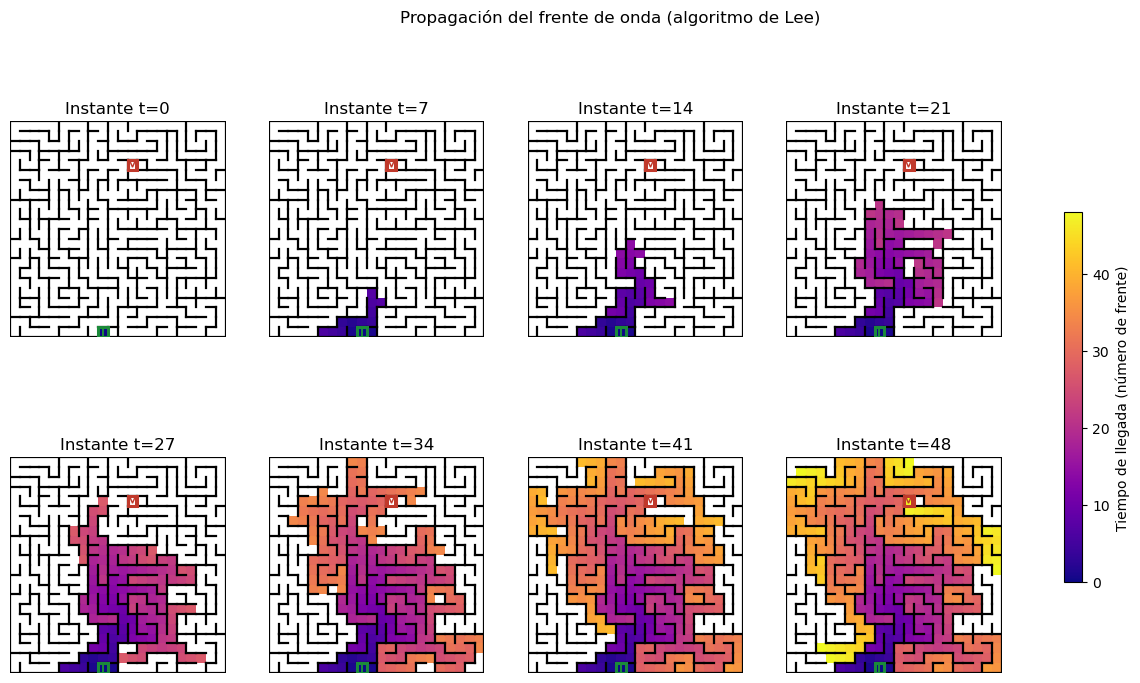

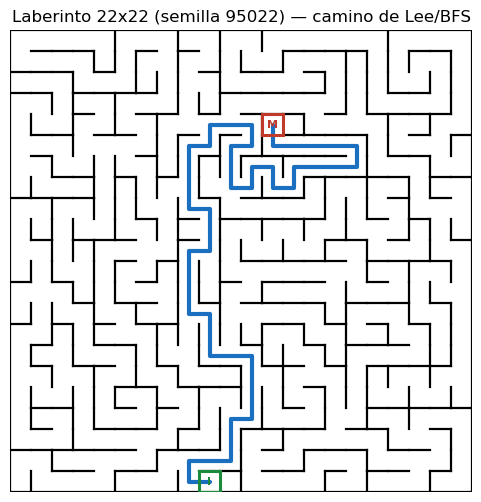

In [10]:
import matplotlib.pyplot as plt
from matplotlib.colors import Normalize
from matplotlib.patches import Rectangle
 
 
def lee_frente_de_onda(problema: ProblemaLaberinto):
    """
    Traduccion directa del pseudocodigo de la seccion 7. Ademas de devolver
    el ResultadoBusqueda, conserva:
      - `etiqueta`: distancia (en numero de aristas) desde `inicio` a cada
        celda alcanzada, tal como exige el pseudocodigo.
      - `historial_frentes`: la lista de frentes en cada instante t,
        necesaria unicamente para poder DIBUJAR la propagacion (no se usa
        para decidir el algoritmo en si).
    (Sin cambios respecto a tu version: el algoritmo ya estaba bien.)
    """
    inicio_t = time.perf_counter()
    etiqueta: Dict[Celda, int] = {problema.inicio: 0}
    procedencia: Dict[Celda, Celda] = {}
    frente_actual = [problema.inicio]
    historial_frentes: List[List[Celda]] = [list(frente_actual)]
 
    expandidos = generados = repetidos_descartados = 0
    frontera_maxima = len(frente_actual)
 
    while frente_actual and problema.meta not in etiqueta:
        frontera_maxima = max(frontera_maxima, len(frente_actual))
        frente_siguiente: List[Celda] = []
        for celda in frente_actual:
            expandidos += 1
            for vecino in problema.acciones(celda):
                generados += 1
                if vecino in etiqueta:
                    repetidos_descartados += 1
                    continue
                etiqueta[vecino] = etiqueta[celda] + 1
                procedencia[vecino] = celda
                frente_siguiente.append(vecino)
        frente_actual = frente_siguiente
        if frente_actual:
            historial_frentes.append(list(frente_actual))
 
    tiempo_ms = (time.perf_counter() - inicio_t) * 1000
 
    if problema.meta not in etiqueta:
        resultado = ResultadoBusqueda(
            encontrado=False, expandidos=expandidos, generados=generados,
            repetidos_descartados=repetidos_descartados,
            frontera_maxima=frontera_maxima, tiempo_ms=tiempo_ms,
        )
        return resultado, etiqueta, historial_frentes
 
    camino = [problema.meta]
    while camino[-1] != problema.inicio:
        camino.append(procedencia[camino[-1]])
    camino.reverse()
    acciones = camino[1:]
 
    resultado = ResultadoBusqueda(
        encontrado=True, camino=camino, acciones=acciones,
        costo=etiqueta[problema.meta], profundidad=etiqueta[problema.meta],
        expandidos=expandidos, generados=generados,
        repetidos_descartados=repetidos_descartados,
        frontera_maxima=frontera_maxima, tiempo_ms=tiempo_ms,
    )
    return resultado, etiqueta, historial_frentes
 
 
def _dibujar_paredes_laberinto(ax, grafo: Grafo, filas: int, columnas: int,
                                color_pared="black", grosor=1.6) -> None:
    """
    Dibuja el laberinto como paredes (igual que un laberinto impreso
    clasico, como tu imagen de referencia): por cada par de celdas
    geometricamente vecinas que NO estan conectadas en el grafo, se traza
    el segmento de pared entre ellas; ademas se dibuja el borde exterior
    completo. La celda (fila, columna) ocupa el cuadrado
    [columna, columna+1] x [fila, fila+1], con el eje Y invertido para que
    la fila 0 quede arriba (como una matriz / como tu imagen de ejemplo).
    """
    ax.set_xlim(0, columnas)
    ax.set_ylim(0, filas)
    ax.invert_yaxis()
    ax.set_aspect("equal")
    ax.axis("off")
 
    ax.plot([0, columnas], [0, 0], color=color_pared, linewidth=grosor)
    ax.plot([0, columnas], [filas, filas], color=color_pared, linewidth=grosor)
    ax.plot([0, 0], [0, filas], color=color_pared, linewidth=grosor)
    ax.plot([columnas, columnas], [0, filas], color=color_pared, linewidth=grosor)
 
    for f in range(filas):
        for c in range(columnas):
            celda = (f, c)
            if c + 1 < columnas and (f, c + 1) not in grafo[celda]:
                ax.plot([c + 1, c + 1], [f, f + 1], color=color_pared, linewidth=grosor)
            if f + 1 < filas and (f + 1, c) not in grafo[celda]:
                ax.plot([c, c + 1], [f + 1, f + 1], color=color_pared, linewidth=grosor)
 
 
def _rellenar_tiempos_de_llegada(ax, etiquetas_acumuladas: Dict[Celda, int],
                                  normalizador, mapa_color) -> None:
    """Colorea cada celda alcanzada segun su tiempo de llegada (se dibuja
    ANTES que las paredes, para que las paredes queden encima, visibles)."""
    for (f, c), t in etiquetas_acumuladas.items():
        ax.add_patch(Rectangle((c, f), 1, 1, facecolor=mapa_color(normalizador(t)),
                                edgecolor="none", zorder=0))
 
 
def _marcar_inicio_y_meta(ax, inicio: Celda, meta: Celda) -> None:
    ax.add_patch(Rectangle((inicio[1], inicio[0]), 1, 1, facecolor="none",
                            edgecolor="#1b8a3a", linewidth=2.2, zorder=3))
    ax.text(inicio[1] + 0.5, inicio[0] + 0.5, "I", color="#1b8a3a", fontsize=8,
            fontweight="bold", ha="center", va="center", zorder=4)
    ax.add_patch(Rectangle((meta[1], meta[0]), 1, 1, facecolor="none",
                            edgecolor="#c0392b", linewidth=2.2, zorder=3))
    ax.text(meta[1] + 0.5, meta[0] + 0.5, "M", color="#c0392b", fontsize=8,
            fontweight="bold", ha="center", va="center", zorder=4)
 
 
def graficar_frentes_lee(historial_frentes, filas, columnas, meta=None,
                          maximo_instantes=8):
    """
    Dibuja como minimo `maximo_instantes` (8 por defecto) instantes de la
    propagacion, coloreados segun el tiempo de llegada acumulado hasta ese
    instante -- ahora sobre el dibujo REAL de paredes del laberinto, no
    sobre una cuadricula de calor abstracta. Ya no guarda archivo: solo
    se muestra en la salida de la celda (plt.show()).
    """
    total_frentes = len(historial_frentes)
    if total_frentes <= maximo_instantes:
        indices_a_mostrar = list(range(total_frentes))
    else:
        paso = (total_frentes - 1) / (maximo_instantes - 1)
        indices_a_mostrar = sorted({round(i * paso) for i in range(maximo_instantes)})
 
    n = len(indices_a_mostrar)
    columnas_fig = min(4, n)
    filas_fig = (n + columnas_fig - 1) // columnas_fig
    fig, ejes = plt.subplots(filas_fig, columnas_fig,
                              figsize=(4 * columnas_fig, 4 * filas_fig))
    ejes = [ejes] if n == 1 else list(ejes.flat)
 
    normalizador = Normalize(vmin=0, vmax=total_frentes - 1)
    mapa_color = plt.cm.plasma
 
    for pos, idx_frente in enumerate(indices_a_mostrar):
        ax = ejes[pos]
        etiquetas_acumuladas = {}
        for t in range(idx_frente + 1):
            for celda in historial_frentes[t]:
                etiquetas_acumuladas[celda] = t
 
        _rellenar_tiempos_de_llegada(ax, etiquetas_acumuladas, normalizador, mapa_color)
        _dibujar_paredes_laberinto(ax, grafo, filas, columnas)
        if meta is not None:
            _marcar_inicio_y_meta(ax, problema_lee.inicio, meta)
        ax.set_title(f"Instante t={idx_frente}")
 
    for pos in range(n, len(ejes)):
        ejes[pos].axis("off")
 
    fig.suptitle("Propagación del frente de onda (algoritmo de Lee)")
    fig.colorbar(
        plt.cm.ScalarMappable(norm=normalizador, cmap=mapa_color),
        ax=ejes, shrink=0.6, label="Tiempo de llegada (número de frente)",
    )
    plt.show()
 
 
def graficar_laberinto_con_camino(grafo: Grafo, filas: int, columnas: int,
                                   inicio: Celda, meta: Celda,
                                   camino: List[Celda]) -> None:
    """
    NUEVO: dibuja el laberinto completo con paredes (estilo laberinto
    impreso, igual que tu imagen de referencia), marca inicio ('I') y
    meta ('M'), y traza encima el camino solucion encontrado por Lee.
    """
    fig, ax = plt.subplots(figsize=(6, 6))
    _dibujar_paredes_laberinto(ax, grafo, filas, columnas)
    xs = [c + 0.5 for (_f, c) in camino]
    ys = [f + 0.5 for (f, _c) in camino]
    ax.plot(xs, ys, color="#1b6fc0", linewidth=3.0, zorder=2, solid_capstyle="round")
    _marcar_inicio_y_meta(ax, inicio, meta)
    ax.set_title(f"Laberinto {filas}x{columnas} (semilla {semilla}) — camino de Lee/BFS")
    plt.show()
 
 
# Ejecución sobre la instancia individual (igual que antes)
problema_lee = ProblemaLaberinto(grafo, inicio, meta)
resultado_lee, etiquetas_lee, historial_frentes = lee_frente_de_onda(problema_lee)
 
print(f"Lee -> encontrado={resultado_lee.encontrado}  "
      f"etiqueta_meta={etiquetas_lee.get(meta)}  "
      f"pasos={resultado_lee.profundidad}  "
      f"tiempo_ms={resultado_lee.tiempo_ms:.3f}")
 
resultado_bfs_verificacion = busqueda_bfs(problema_lee)
assert etiquetas_lee[meta] == resultado_bfs_verificacion.profundidad, (
    "La etiqueta de Lee en la meta DEBE coincidir con la profundidad de BFS: "
    f"Lee={etiquetas_lee[meta]} vs BFS={resultado_bfs_verificacion.profundidad}"
)
print("Verificación OK: etiqueta_meta(Lee) == profundidad(BFS) "
      f"= {etiquetas_lee[meta]}")
 
# Visualización obligatoria: al menos 8 instantes del frente, con paredes reales
graficar_frentes_lee(historial_frentes, filas, columnas, meta=meta, maximo_instantes=8)
 
# Visualización adicional que pediste: laberinto completo con el camino trazado
graficar_laberinto_con_camino(grafo, filas, columnas, inicio, meta, resultado_lee.camino)

# Versión 2 — SimpleAI

Instalación orientativa:

```text
pip install simpleai
```

Consulte la documentación oficial. Debe crear una subclase de `SearchProblem` y definir, como mínimo:

| Método de SimpleAI | Responsabilidad en el laberinto |
|---|---|
| `actions(state)` | Producir únicamente movimientos legales |
| `result(state, action)` | Calcular el estado sucesor sin mutar el original |
| `is_goal(state)` | Reconocer la celda meta |
| `cost(state, action, state2)` | Devolver el costo del corredor |

Instancie el problema con un estado inicial inmutable y use `graph_search=True`.

Debe ejecutar y estudiar:

- `depth_first`;
- `breadth_first`;
- `uniform_cost`;
- `limited_depth_first`;
- `iterative_limited_depth_first`.

### Exigencia avanzada

SimpleAI devuelve un nodo solución, pero las métricas del contrato no aparecen automáticamente con la misma definición. Investigue su mecanismo de *viewer* o diseñe instrumentación externa **sin modificar el código fuente instalado de la biblioteca**. Documente cualquier diferencia entre las métricas de SimpleAI y las de su versión.

No copie la estructura de su buscador desde cero dentro de esta versión: el propósito es construir correctamente el adaptador del problema y comprender la biblioteca.

In [ ]:
# VERSIÓN 2: modele el problema y ejecute SimpleAI.
from collections import deque
from dataclasses import dataclass
import csv
import importlib
import math
import random
import statistics
import time
from typing import Any, Callable, Dict, Iterable, List, Mapping, Optional, Sequence, Tuple


@dataclass
class ResultadoAdaptador:
    """Resultado compatible con el contrato, indicando metricas no expuestas."""
    encontrado: bool
    camino: List[Any]
    acciones: List[Any]
    costo: float
    profundidad: int
    expandidos: Optional[int]
    generados: Optional[int]
    repetidos_descartados: Optional[int]
    frontera_maxima: Optional[int]
    tiempo_ms: float
    llamadas_acciones: Optional[int] = None


@dataclass
class InstrumentacionBiblioteca:
    llamadas_acciones: int = 0
    sucesores_considerados: int = 0
    llamadas_costo: int = 0


def _crear_resultado_desde_nodo(nodo, problema, instrumentacion):
    """Normaliza nodos AIMA/SimpleAI sin depender de su formato de impresion."""
    if nodo is None or isinstance(nodo, str):
        return ResultadoAdaptador(
            encontrado=False, camino=[], acciones=[], costo=math.inf,
            profundidad=0,
            expandidos=instrumentacion.llamadas_acciones,
            generados=instrumentacion.sucesores_considerados,
            repetidos_descartados=None, frontera_maxima=None,
            tiempo_ms=0.0,
            llamadas_acciones=instrumentacion.llamadas_acciones,
        )

    nodos = []
    actual = nodo
    while actual is not None:
        nodos.append(actual)
        actual = getattr(actual, "parent", None)
    nodos.reverse()
    camino = [nodo_busqueda.state for nodo_busqueda in nodos]
    acciones = [nodo_busqueda.action for nodo_busqueda in nodos[1:]]
    costo = sum(
        problema.costo_paso(origen, destino, destino)
        for origen, destino in zip(camino, camino[1:])
    )
    return ResultadoAdaptador(
        encontrado=bool(camino) and camino[-1] == problema.meta,
        camino=camino,
        acciones=acciones,
        costo=costo,
        profundidad=max(0, len(camino) - 1),
        expandidos=instrumentacion.llamadas_acciones,
        generados=instrumentacion.sucesores_considerados,
        repetidos_descartados=None,
        frontera_maxima=None,
        tiempo_ms=0.0,
        llamadas_acciones=instrumentacion.llamadas_acciones,
    )


def _resultado_con_tiempo(nodo, problema, instrumentacion, inicio_reloj):
    resultado = _crear_resultado_desde_nodo(nodo, problema, instrumentacion)
    resultado.tiempo_ms = (time.perf_counter() - inicio_reloj) * 1000
    return resultado


def ejecutar_simpleai(problema, algoritmo: str, limite: Optional[int] = None):
    """Ejecuta un algoritmo SimpleAI y devuelve el contrato mas instrumentacion.

    SimpleAI no expone de forma uniforme repetidos descartados ni frontera
    maxima. `expandidos` equivale aqui a llamadas a actions(); `generados` a
    movimientos legales devueltos por esas llamadas, no a nodos aceptados.
    """
    try:
        modulo_simpleai = importlib.import_module("simpleai.search")
    except ImportError as error:
        raise ImportError(
            "Instala SimpleAI en el kernel con %pip install simpleai"
        ) from error
    SearchProblem = modulo_simpleai.SearchProblem

    instrumentacion = InstrumentacionBiblioteca()

    class ProblemaLaberintoSimpleAI(SearchProblem):
        def __init__(self):
            super().__init__(problema.inicio)

        def actions(self, state):
            instrumentacion.llamadas_acciones += 1
            acciones = sorted(problema.grafo[state])
            instrumentacion.sucesores_considerados += len(acciones)
            return acciones

        def result(self, state, action):
            return action

        def is_goal(self, state):
            return state == problema.meta

        def cost(self, state, action, state2):
            instrumentacion.llamadas_costo += 1
            return problema.costo_paso(state, action, state2)

    instancia = ProblemaLaberintoSimpleAI()
    inicio_reloj = time.perf_counter()
    if algoritmo == "DFS":
        nodo = modulo_simpleai.depth_first(instancia, graph_search=True)
    elif algoritmo == "BFS":
        nodo = modulo_simpleai.breadth_first(instancia, graph_search=True)
    elif algoritmo == "UCS":
        nodo = modulo_simpleai.uniform_cost(instancia, graph_search=True)
    elif algoritmo == "DLS":
        limite = len(problema.grafo) if limite is None else limite
        nodo = modulo_simpleai.limited_depth_first(
            instancia, limite, graph_search=True
        )
    elif algoritmo == "IDDFS":
        nodo = modulo_simpleai.iterative_limited_depth_first(
            instancia, graph_search=True
        )
    else:
        raise ValueError(f"Algoritmo SimpleAI desconocido: {algoritmo}")

    return _resultado_con_tiempo(nodo, problema, instrumentacion, inicio_reloj)

# Versión 3 — AIMA-Python

Repositorio de referencia: `aimacode/aima-python`.

Debe modelar el laberinto como una subclase de `Problem`. Investigue y documente los contratos de:

| Método de AIMA-Python | Decisión requerida |
|---|---|
| `actions(state)` | Formato de las acciones y orden determinista |
| `result(state, action)` | Transición entre celdas |
| `goal_test(state)` | Prueba de objetivo |
| `path_cost(c, state1, action, state2)` | Acumulación de costos |

Compare al menos:

- `depth_first_graph_search`;
- `breadth_first_graph_search`;
- `uniform_cost_search`;
- `depth_limited_search`;
- `iterative_deepening_search`;
- `bidirectional_search`.

### Exigencia avanzada

Instrumente los algoritmos sin alterar permanentemente el repositorio. Puede utilizar una subclase del problema, envoltorios o contadores cuidadosamente definidos. Explique por qué contar llamadas a `actions` no siempre coincide con contar nodos generados.

Compare la representación del nodo de AIMA-Python con su propia clase de nodo.

In [ ]:
# VERSIÓN 3: adapte el problema a AIMA-Python.
def _importar_modulo_busqueda_aima():
    errores = []
    for nombre_modulo in ("aima.search", "aima3.search", "search"):
        try:
            return importlib.import_module(nombre_modulo)
        except ImportError as error:
            errores.append(error)
    raise ImportError(
        "No se encontro search.py de AIMA-Python. Instala la distribucion "
        "usada por el curso o agrega su carpeta al path del kernel."
    ) from errores[-1]


def ejecutar_aima(problema, algoritmo: str, limite: Optional[int] = None):
    """Adapta ProblemaLaberinto a Problem y usa funciones de AIMA-Python."""
    modulo = _importar_modulo_busqueda_aima()
    instrumentacion = InstrumentacionBiblioteca()

    class ProblemaLaberintoAIMA(modulo.Problem):
        def __init__(self):
            super().__init__(problema.inicio, problema.meta)

        def actions(self, state):
            instrumentacion.llamadas_acciones += 1
            acciones = sorted(problema.grafo[state])
            instrumentacion.sucesores_considerados += len(acciones)
            return acciones

        def result(self, state, action):
            return action

        def goal_test(self, state):
            return state == problema.meta

        def path_cost(self, cost_so_far, state1, action, state2):
            instrumentacion.llamadas_costo += 1
            return cost_so_far + problema.costo_paso(state1, action, state2)

    instancia = ProblemaLaberintoAIMA()
    inicio_reloj = time.perf_counter()
    if algoritmo == "DFS":
        nodo = modulo.depth_first_graph_search(instancia)
    elif algoritmo == "BFS":
        nodo = modulo.breadth_first_graph_search(instancia)
    elif algoritmo == "UCS":
        nodo = modulo.uniform_cost_search(instancia)
    elif algoritmo == "DLS":
        limite = len(problema.grafo) if limite is None else limite
        nodo = modulo.depth_limited_search(instancia, limit=limite)
    elif algoritmo == "IDDFS":
        nodo = modulo.iterative_deepening_search(instancia)
    elif algoritmo == "BIDIRECCIONAL":
        nodo = modulo.bidirectional_search(instancia)
    else:
        raise ValueError(f"Algoritmo AIMA-Python desconocido: {algoritmo}")

    return _resultado_con_tiempo(nodo, problema, instrumentacion, inicio_reloj)

## 8. Pruebas de aceptación

El estudiante debe implementar pruebas automáticas equivalentes a las siguientes especificaciones, sin recibir su solución:

### Validez de un camino

Para cada resultado exitoso:

1. el primer estado es el inicio;
2. el último estado es la meta;
3. cada pareja consecutiva aparece como arista en el grafo;
4. el costo reportado coincide con la suma de costos;
5. aplicar las acciones reproduce exactamente los estados.

### Concordancia entre versiones

- En costos unitarios: `longitud(BFS) = longitud(UCS) = etiqueta_meta(Lee)`.
- En un árbol: todas las soluciones válidas contienen la misma secuencia de estados.
- Con ciclos: `longitud(BFS) ≤ longitud(DFS)` para una DFS que encuentre solución.
- Con costos positivos: `costo(UCS) ≤ costo(cualquier solución BFS)`.
- Las tres versiones deben concordar en existencia de solución y costo óptimo.

### Casos límite obligatorios

- inicio igual a meta;
- laberinto de `1×1`;
- meta inalcanzable después de eliminar corredores;
- múltiples entradas obsoletas en UCS;
- dos posibles puntos de encuentro bidireccional;
- límite exacto, insuficiente y excesivo en búsqueda limitada.

In [11]:
import unittest
 
 
def verificar_camino_valido(problema: ProblemaLaberinto, resultado: ResultadoBusqueda) -> None:
    #Verificación independiente de un ResultadoBusqueda exitoso, según las 5 condiciones de "Validez de un camino" de la sección 8.
    if not resultado.encontrado:
        assert resultado.camino == [], "camino debe ser vacío si no hay solución"
        return
 
    camino = resultado.camino
    assert camino[0] == problema.inicio, "el primer estado debe ser el inicio"
    assert camino[-1] == problema.meta, "el último estado debe ser la meta"
 
    for a, b in zip(camino, camino[1:]):
        assert b in problema.grafo[a], f"({a}, {b}) no es una arista del grafo"
 
    costo_recalculado = sum(
        problema.costo_paso(a, b, b) for a, b in zip(camino, camino[1:])
    )
    assert abs(costo_recalculado - resultado.costo) < 1e-9, (
        f"costo reportado ({resultado.costo}) != costo recalculado ({costo_recalculado})"
    )
 
    estado_simulado = problema.inicio
    estados_simulados = [estado_simulado]
    for accion in resultado.acciones:
        estado_simulado = problema.resultado(estado_simulado, accion)
        estados_simulados.append(estado_simulado)
    assert estados_simulados == camino, "aplicar las acciones no reproduce el camino"
 
 
class TestAceptacion(unittest.TestCase):
 
    # Validez de camino sobre el laberinto real (árbol)
    def setUp(self):
        self.grafo = grafo    # instancia individual
        self.filas = filas
        self.columnas = columnas
        self.inicio = inicio
        self.meta = meta
        self.problema = ProblemaLaberinto(self.grafo, self.inicio, self.meta)
 
    def test_dfs_produce_camino_valido(self):
        resultado = busqueda_dfs(self.problema)
        self.assertTrue(resultado.encontrado)
        verificar_camino_valido(self.problema, resultado)
 
    def test_bfs_produce_camino_valido(self):
        resultado = busqueda_bfs(self.problema)
        self.assertTrue(resultado.encontrado)
        verificar_camino_valido(self.problema, resultado)
 
    def test_ucs_produce_camino_valido(self):
        resultado = busqueda_costo_uniforme(self.problema)
        self.assertTrue(resultado.encontrado)
        verificar_camino_valido(self.problema, resultado)
 
    def test_bidireccional_produce_camino_valido(self):
        resultado = busqueda_bidireccional(self.problema)
        self.assertTrue(resultado.encontrado)
        verificar_camino_valido(self.problema, resultado)
 
    def test_iddfs_produce_camino_valido(self):
        resultado = busqueda_profundizacion_iterativa(self.problema)
        self.assertTrue(resultado.encontrado)
        verificar_camino_valido(self.problema, resultado)
 
    def test_lee_produce_camino_valido(self):
        resultado, _etq, _hist = lee_frente_de_onda(self.problema)
        self.assertTrue(resultado.encontrado)
        verificar_camino_valido(self.problema, resultado)
 
    # Concordancia entre algoritmos (árbol, costo unitario) 
    def test_bfs_ucs_lee_coinciden_en_longitud(self):
        r_bfs = busqueda_bfs(self.problema)
        r_ucs = busqueda_costo_uniforme(self.problema)
        r_lee, etiquetas, _ = lee_frente_de_onda(self.problema)
        self.assertEqual(len(r_bfs.camino), len(r_ucs.camino))
        self.assertEqual(etiquetas[self.meta], r_bfs.profundidad)
        self.assertEqual(r_lee.profundidad, r_bfs.profundidad)
 
    def test_en_arbol_todas_las_soluciones_coinciden(self):
        # Es un árbol: el camino es único, así que BFS, UCS y Lee deben devolver EXACTAMENTE la misma secuencia de estados.
        r_bfs = busqueda_bfs(self.problema)
        r_ucs = busqueda_costo_uniforme(self.problema)
        r_lee, _, _ = lee_frente_de_onda(self.problema)
        self.assertEqual(r_bfs.camino, r_ucs.camino)
        self.assertEqual(r_bfs.camino, r_lee.camino)
 
    # Concordancia con ciclos y costos (reutiliza el punto 9)
    def test_bfs_mas_corto_o_igual_que_dfs_con_ciclos(self):
        grafo_ciclico, _frac, _n = agregar_ciclos(self.grafo, self.filas, self.columnas, semilla)
        problema_ciclico = ProblemaLaberinto(grafo_ciclico, self.inicio, self.meta)
        r_bfs = busqueda_bfs(problema_ciclico)
        r_dfs = busqueda_dfs(problema_ciclico)
        self.assertTrue(r_bfs.encontrado and r_dfs.encontrado)
        self.assertLessEqual(len(r_bfs.camino), len(r_dfs.camino))
        verificar_camino_valido(problema_ciclico, r_bfs)
        verificar_camino_valido(problema_ciclico, r_dfs)
 
    def test_ucs_costo_menor_o_igual_a_bfs_con_pesos(self):
        grafo_ciclico, _frac, _n = agregar_ciclos(self.grafo, self.filas, self.columnas, semilla)
        costos = asignar_costos(grafo_ciclico, semilla)
        problema_base = ProblemaLaberinto(grafo_ciclico, self.inicio, self.meta)
        costos = forzar_divergencia_pasos_costo(problema_base, costos)
        problema_ponderado = ProblemaLaberinto(grafo_ciclico, self.inicio, self.meta, costos=costos)
 
        r_bfs = busqueda_bfs(problema_ponderado)
        r_ucs = busqueda_costo_uniforme(problema_ponderado)
        costo_bfs = sum(
            problema_ponderado.costo_paso(a, b, b)
            for a, b in zip(r_bfs.camino, r_bfs.camino[1:])
        )
        self.assertLessEqual(r_ucs.costo, costo_bfs)
        verificar_camino_valido(problema_ponderado, r_ucs)
 
    def test_ucs_con_multiples_entradas_obsoletas(self):
        # Grafo pequeño hecho a mano (independiente del laberinto) donde el mismo nodo D es alcanzado por varias rutas de costo
        # decreciente, forzando entradas obsoletas en el heap de UCS antes de llegar al costo óptimo real.
        grafo_pequeno = {
            "A": {"B", "C", "F"}, "B": {"A", "D"}, "C": {"A", "D"},
            "F": {"A", "D"}, "D": {"A", "B", "C", "F"},
        }
        costos_pequenos = {
            frozenset({"A", "B"}): 5, frozenset({"B", "D"}): 5,  
            frozenset({"A", "C"}): 3, frozenset({"C", "D"}): 3,   
            frozenset({"A", "F"}): 1, frozenset({"F", "D"}): 1,   
        }
        problema_pequeno = ProblemaLaberinto(grafo_pequeno, "A", "D", costos=costos_pequenos)
        resultado = busqueda_costo_uniforme(problema_pequeno)
        self.assertEqual(resultado.costo, 2)
        self.assertEqual(resultado.camino, ["A", "F", "D"])
        verificar_camino_valido(problema_pequeno, resultado)
 
    # ---------- casos límite obligatorios ----------
    def test_inicio_igual_a_meta(self):
        celda_cualquiera = next(iter(self.grafo))
        problema_trivial = ProblemaLaberinto(self.grafo, celda_cualquiera, celda_cualquiera)
        for algoritmo in (busqueda_bfs, busqueda_dfs, busqueda_costo_uniforme,
                          busqueda_bidireccional):
            resultado = algoritmo(problema_trivial)
            self.assertTrue(resultado.encontrado)
            self.assertEqual(resultado.camino, [celda_cualquiera])
            self.assertEqual(resultado.costo, 0)
            self.assertEqual(resultado.expandidos, 0)
 
    def test_laberinto_1x1(self):
        grafo_1x1 = LaberintoHuntKill(filas=1, columnas=1, semilla=1).generar()
        problema_1x1 = ProblemaLaberinto(grafo_1x1, (0, 0), (0, 0))
        resultado = busqueda_bfs(problema_1x1)
        self.assertTrue(resultado.encontrado)
        self.assertEqual(resultado.camino, [(0, 0)])
 
    def test_meta_inalcanzable(self):
        grafo_roto = {k: set(v) for k, v in self.grafo.items()}
        for vecino in list(grafo_roto[self.meta]):
            grafo_roto[vecino].discard(self.meta)
        grafo_roto[self.meta] = set()
 
        problema_roto = ProblemaLaberinto(grafo_roto, self.inicio, self.meta)
        for algoritmo in (busqueda_bfs, busqueda_dfs, busqueda_costo_uniforme,
                          busqueda_bidireccional):
            resultado = algoritmo(problema_roto)
            self.assertFalse(resultado.encontrado)
            self.assertEqual(resultado.camino, [])
 
        resultado_lee, etiquetas, _ = lee_frente_de_onda(problema_roto)
        self.assertFalse(resultado_lee.encontrado)
        self.assertNotIn(self.meta, etiquetas)
 
    def test_dos_puntos_de_encuentro_bidireccional(self):
        # Ciclo simple hecho a mano: hay DOS puntos de encuentro posibles entre las ondas que avanzan desde "A" y desde "D".
        #      A - B - D
        #      A - C - D
        grafo_ciclo = {"A": {"B", "C"}, "B": {"A", "D"},
                       "C": {"A", "D"}, "D": {"B", "C"}}
        problema_ciclo = ProblemaLaberinto(grafo_ciclo, "A", "D")
        resultado = busqueda_bidireccional(problema_ciclo)
        self.assertTrue(resultado.encontrado)
        self.assertIn(resultado.camino, (["A", "B", "D"], ["A", "C", "D"]))
        verificar_camino_valido(problema_ciclo, resultado)
 
    def test_limite_de_profundidad_exacto_insuficiente_y_excesivo(self):
        r_bfs = busqueda_bfs(self.problema)
        profundidad_real = r_bfs.profundidad
 
        _res_insuf, corte_insuf = busqueda_limitada_profundidad(
            self.problema, profundidad_real - 1
        )
        self.assertFalse(_res_insuf.encontrado)
        self.assertTrue(corte_insuf)  # corte, no fracaso definitivo
 
        res_exacto, _corte_exacto = busqueda_limitada_profundidad(
            self.problema, profundidad_real
        )
        self.assertTrue(res_exacto.encontrado)
        verificar_camino_valido(self.problema, res_exacto)
 
        res_excesivo, _corte_excesivo = busqueda_limitada_profundidad(
            self.problema, profundidad_real + 5
        )
        self.assertTrue(res_excesivo.encontrado)
        verificar_camino_valido(self.problema, res_excesivo)
 
suite = unittest.TestLoader().loadTestsFromTestCase(TestAceptacion)
unittest.TextTestRunner(verbosity=2).run(suite)

test_bfs_mas_corto_o_igual_que_dfs_con_ciclos (__main__.TestAceptacion.test_bfs_mas_corto_o_igual_que_dfs_con_ciclos) ... ERROR
test_bfs_produce_camino_valido (__main__.TestAceptacion.test_bfs_produce_camino_valido) ... ok
test_bfs_ucs_lee_coinciden_en_longitud (__main__.TestAceptacion.test_bfs_ucs_lee_coinciden_en_longitud) ... ok
test_bidireccional_produce_camino_valido (__main__.TestAceptacion.test_bidireccional_produce_camino_valido) ... ok
test_dfs_produce_camino_valido (__main__.TestAceptacion.test_dfs_produce_camino_valido) ... ok
test_dos_puntos_de_encuentro_bidireccional (__main__.TestAceptacion.test_dos_puntos_de_encuentro_bidireccional) ... ok
test_en_arbol_todas_las_soluciones_coinciden (__main__.TestAceptacion.test_en_arbol_todas_las_soluciones_coinciden) ... ok
test_iddfs_produce_camino_valido (__main__.TestAceptacion.test_iddfs_produce_camino_valido) ... ok
test_inicio_igual_a_meta (__main__.TestAceptacion.test_inicio_igual_a_meta) ... ok
test_laberinto_1x1 (__main__.Tes

<unittest.runner.TextTestResult run=16 errors=2 failures=0>

## 9. Segunda familia de problemas: ciclos y costos

Hunt-and-Kill produce un árbol. Allí existe un único camino entre dos estados y no se aprecia plenamente la optimalidad. Diseñe, sin modificar el generador original, dos transformaciones:

### A. Laberinto con ciclos

Abra aleatoriamente entre 5% y 12% de las paredes internas que no sean corredores. Debe conservar:

- adyacencias ortogonales;
- simetría del grafo;
- reproducibilidad;
- al menos un ciclo comprobable.

### B. Laberinto ponderado

Asigne costos positivos a corredores o terrenos. Construya deliberadamente un caso donde:

```text
camino con menos pasos ≠ camino de menor costo
```

No use pesos negativos. Justifique si los costos pertenecen a celdas, acciones o aristas y mantenga esa decisión en las tres versiones.

In [ ]:
def agregar_ciclos(grafo, filas: int, columnas: int, semilla: int,
                   fraccion: float = 0.05):
    """Abre una fraccion reproducible de paredes interiores, sin mutar grafo."""
    if not 0.05 <= fraccion <= 0.12:
        raise ValueError("La fraccion debe estar entre 0.05 y 0.12")
    grafo_nuevo = {estado: set(vecinos) for estado, vecinos in grafo.items()}
    paredes = []
    for fila in range(filas):
        for columna in range(columnas):
            estado = (fila, columna)
            if columna + 1 < columnas:
                vecino = (fila, columna + 1)
                if vecino not in grafo_nuevo[estado]:
                    paredes.append((estado, vecino))
            if fila + 1 < filas:
                vecino = (fila + 1, columna)
                if vecino not in grafo_nuevo[estado]:
                    paredes.append((estado, vecino))
    if not paredes:
        raise ValueError("No hay paredes cerradas para abrir")
    cantidad_minima = math.ceil(0.05 * len(paredes))
    cantidad_maxima = math.floor(0.12 * len(paredes))
    if cantidad_minima > cantidad_maxima:
        raise ValueError(
            "La malla es demasiado pequena para cumplir el intervalo de 5%-12% "
            "y abrir al menos una pared"
        )
    cantidad = min(
        cantidad_maxima,
        max(cantidad_minima, round(fraccion * len(paredes))),
    )
    rng = random.Random(semilla)
    abiertas = rng.sample(paredes, min(cantidad, len(paredes)))
    for origen, destino in abiertas:
        grafo_nuevo[origen].add(destino)
        grafo_nuevo[destino].add(origen)
    return grafo_nuevo, len(abiertas) / len(paredes), len(abiertas)


def aristas_no_dirigidas(grafo):
    return {
        frozenset((origen, destino))
        for origen, vecinos in grafo.items()
        for destino in vecinos
        if origen != destino
    }


def validar_costos_positivos(grafo, costos) -> None:
    """Rechaza mapas incompletos, no finitos o no estrictamente positivos."""
    requeridas = aristas_no_dirigidas(grafo)
    faltantes = requeridas - set(costos)
    if faltantes:
        raise ValueError(f"Faltan costos para {len(faltantes)} corredores")
    for arista in requeridas:
        costo = costos[arista]
        if not math.isfinite(costo) or costo <= 0:
            raise ValueError(f"Costo invalido para {arista}: {costo}")


def asignar_costos(grafo, semilla: int, minimo: int = 1, maximo: int = 9):
    """Asigna costos enteros positivos reproducibles a las aristas."""
    if minimo <= 0 or maximo < minimo:
        raise ValueError("El rango debe ser positivo y maximo >= minimo")
    rng = random.Random(semilla)
    costos = {
        arista: rng.randint(minimo, maximo)
        for arista in aristas_no_dirigidas(grafo)
    }
    validar_costos_positivos(grafo, costos)
    return costos


def _camino_bfs(problema, arista_bloqueada=None):
    """BFS pequeno para construir rutas de referencia y probar pesos."""
    inicio = problema.inicio
    meta = problema.meta
    cola = deque([inicio])
    padre = {inicio: None}
    while cola:
        actual = cola.popleft()
        if actual == meta:
            camino = []
            while actual is not None:
                camino.append(actual)
                actual = padre[actual]
            return list(reversed(camino))
        for vecino in problema.acciones(actual):
            if arista_bloqueada == frozenset((actual, vecino)):
                continue
            if vecino not in padre:
                padre[vecino] = actual
                cola.append(vecino)
    return []


def forzar_divergencia_pasos_costo(problema, costos_existentes=None):
    """Hace que una ruta de mas pasos cueste menos que toda ruta mas corta.

    Requiere que haya una ruta alternativa estrictamente mas larga entre las
    mismas puntas. Si el grafo no la tiene, se informa en vez de simularla.
    """
    camino_corto = _camino_bfs(problema)
    if not camino_corto:
        raise ValueError("Inicio y meta no estan conectados")
    camino_alternativo = []
    for origen, destino in zip(camino_corto, camino_corto[1:]):
        candidato = _camino_bfs(
            problema, arista_bloqueada=frozenset((origen, destino))
        )
        if len(candidato) > len(camino_corto):
            camino_alternativo = candidato
            break
    if not camino_alternativo:
        raise ValueError(
            "No existe una ruta mas larga alternativa; use un grafo con un ciclo "
            "que conecte dos puntos del recorrido inicio-meta."
        )

    todas = aristas_no_dirigidas(problema.grafo)
    costo_alto = len(problema.grafo) + 1
    costos = {arista: costo_alto for arista in todas}
    for origen, destino in zip(camino_alternativo, camino_alternativo[1:]):
        costos[frozenset((origen, destino))] = 1
    validar_costos_positivos(problema.grafo, costos)
    assert len(camino_alternativo) > len(camino_corto)
    assert sum(costos[frozenset((a, b))] for a, b in zip(
        camino_alternativo, camino_alternativo[1:]
    )) < sum(costos[frozenset((a, b))] for a, b in zip(
        camino_corto, camino_corto[1:]
    ))
    return costos


def problema_demo_ponderado(constructor_problema):
    """Caso controlado: BFS usa 2 pasos; UCS prefiere 3 pasos de costo 1."""
    grafo = {
        "A": {"B", "C"},
        "B": {"A", "D"},
        "C": {"A", "E"},
        "E": {"C", "D"},
        "D": {"B", "E"},
    }
    costos = {
        frozenset(("A", "B")): 10,
        frozenset(("B", "D")): 10,
        frozenset(("A", "C")): 1,
        frozenset(("C", "E")): 1,
        frozenset(("E", "D")): 1,
    }
    validar_costos_positivos(grafo, costos)
    return constructor_problema(grafo, "A", "D", costos=costos)


def validar_laberinto_ciclico(grafo, grafo_arbol, filas: int, columnas: int,
                               fraccion_abierta: float) -> None:
    """Verifica simetria, ortogonalidad, conectividad y al menos un ciclo."""
    assert set(grafo) == set(grafo_arbol)
    for estado, vecinos in grafo.items():
        fila, columna = estado
        assert 0 <= fila < filas and 0 <= columna < columnas
        for vecino in vecinos:
            assert estado in grafo[vecino], f"Arista asimetrica: {estado}->{vecino}"
            assert abs(fila - vecino[0]) + abs(columna - vecino[1]) == 1
    raiz = next(iter(grafo))
    alcanzados = {raiz}
    pila = [raiz]
    while pila:
        actual = pila.pop()
        for vecino in grafo[actual]:
            if vecino not in alcanzados:
                alcanzados.add(vecino)
                pila.append(vecino)
    assert len(alcanzados) == len(grafo), "El grafo debe seguir conexo"
    aristas = sum(len(vecinos) for vecinos in grafo.values()) // 2
    aristas_base = sum(len(vecinos) for vecinos in grafo_arbol.values()) // 2
    assert aristas_base == len(grafo_arbol) - 1, "La base debe ser un arbol"
    assert aristas > aristas_base, "La extension debe contener al menos un ciclo"
    assert 0.05 <= fraccion_abierta <= 0.12


def probar_reproducibilidad_extension(grafo, filas, columnas, semilla):
    grafo_a, fraccion_a, abiertas_a = agregar_ciclos(
        grafo, filas, columnas, semilla, 0.05
    )
    grafo_b, fraccion_b, abiertas_b = agregar_ciclos(
        grafo, filas, columnas, semilla, 0.05
    )
    assert grafo_a == grafo_b and fraccion_a == fraccion_b
    assert abiertas_a == abiertas_b
    costos_a = asignar_costos(grafo_a, semilla)
    costos_b = asignar_costos(grafo_a, semilla)
    assert costos_a == costos_b
    return grafo_a, costos_a


def probar_ucs_entradas_obsoletas(ucs_solver, constructor_problema):
    """Hace que UCS inserte costos mejores repetidos antes de extraer la meta."""
    grafo = {
        "A": {"B", "C", "F"},
        "B": {"A", "D"},
        "C": {"A", "D"},
        "F": {"A", "D"},
        "D": {"B", "C", "F", "G"},
        "G": {"D"},
    }
    costos = {
        frozenset(("A", "B")): 5,
        frozenset(("B", "D")): 5,
        frozenset(("A", "C")): 3,
        frozenset(("C", "D")): 3,
        frozenset(("A", "F")): 1,
        frozenset(("F", "D")): 1,
        frozenset(("D", "G")): 100,
    }
    problema = constructor_problema(grafo, "A", "G", costos=costos)
    resultado = ucs_solver(problema)
    assert resultado.encontrado
    assert resultado.camino == ["A", "F", "D", "G"]
    assert resultado.costo == 102
    verificar_camino_valido(problema, resultado)
    return resultado


def probar_bidir_dos_intersecciones(bidirectional_solver, constructor_problema):
    """Comprueba reconstruccion en un rombo con dos intersecciones posibles."""
    grafo = {
        "A": {"B", "C"},
        "B": {"A", "D"},
        "C": {"A", "D"},
        "D": {"B", "C"},
    }
    problema = constructor_problema(grafo, "A", "D")
    resultado = bidirectional_solver(problema)
    assert resultado.encontrado
    assert resultado.camino in (["A", "B", "D"], ["A", "C", "D"])
    verificar_camino_valido(problema, resultado)
    return resultado


def probar_limites_dls(problema, bfs_solver, dls_solver):
    """Comprueba limite insuficiente, exacto y excesivo en DLS propio."""
    profundidad = bfs_solver(problema).profundidad
    resultado_corte, hubo_corte = dls_solver(problema, profundidad - 1)
    assert not resultado_corte.encontrado and hubo_corte
    resultado_exacto, _ = dls_solver(problema, profundidad)
    assert resultado_exacto.encontrado
    resultado_excesivo, _ = dls_solver(problema, profundidad + 5)
    assert resultado_excesivo.encontrado
    for resultado in (resultado_exacto, resultado_excesivo):
        verificar_camino_valido(problema, resultado)
    return resultado_corte, resultado_exacto, resultado_excesivo


def probar_divergencia_bfs_ucs(constructor_problema, bfs_solver, ucs_solver):
    problema = problema_demo_ponderado(constructor_problema)
    resultado_bfs = bfs_solver(problema)
    resultado_ucs = ucs_solver(problema)
    assert resultado_bfs.profundidad == 2
    assert resultado_ucs.profundidad == 3
    assert resultado_ucs.costo < resultado_bfs.costo
    verificar_camino_valido(problema, resultado_bfs)
    verificar_camino_valido(problema, resultado_ucs)
    return resultado_bfs, resultado_ucs

## 10. Diseño experimental

Ejecute como mínimo **30 instancias** por configuración y reporte mediana y rango intercuartílico, no solamente un caso.

| Factor | Niveles mínimos |
|---|---|
| Tamaño | 15×15, 25×25, 40×40 |
| Topología | árbol, 5% ciclos, 10% ciclos |
| Costos | unitarios, ponderados |
| Posición | esquinas, interior, cercanas |
| Algoritmos | todos los exigidos que sean aplicables |

Debe controlar semillas y separar tiempo de generación del tiempo de búsqueda.

### Gráficas obligatorias

1. expandidos frente a número de estados;
2. frontera máxima frente a profundidad de solución;
3. tiempo frente a tamaño;
4. costo y longitud de las soluciones;
5. mapa de calor de Lee;
6. comparación cruzada de las tres versiones.

### Discusión obligatoria

- ¿Qué métrica resulta más estable que el tiempo?
- ¿Cuándo la búsqueda bidireccional pierde su ventaja?
- ¿Por qué IDDFS repite trabajo y aun así puede ser conveniente?
- ¿Qué efecto tiene el orden de sucesores sobre DFS?
- ¿Qué parte de las diferencias se debe al algoritmo y cuál a la biblioteca?

In [ ]:
# Construya aquí su protocolo experimental, tablas y gráficas.

## 11. Análisis teórico

Complete y justifique esta tabla usando $b$ como factor de ramificación, $d$ como profundidad de la solución menos profunda y $m$ como profundidad máxima.

| Algoritmo | Completo | Óptimo | Tiempo | Espacio | Condiciones |
|---|---|---|---|---|---|
| DFS | | | | | |
| BFS | | | | | |
| UCS | | | | | |
| DLS | | | | | |
| IDDFS | | | | | |
| Bidireccional | | | | | |
| Lee | | | | | |

Relacione después las cotas teóricas con las mediciones. Una tabla memorizada sin conexión con los experimentos no recibe puntaje completo.

## 12. Preguntas para la defensa

El docente seleccionará algunas al azar:

1. Muestre en memoria la diferencia entre frontera y alcanzados.
2. Cambie BFS a DFS modificando solamente la política apropiada.
3. Explique un caso en el que marcar visitados demasiado tarde duplique trabajo.
4. Explique por qué terminar UCS al generar la meta puede ser incorrecto.
5. Reconstruya un camino usando padres sin almacenar caminos completos.
6. Muestre por qué dos BFS bidireccionales requieren orientar correctamente los padres.
7. Explique por qué Lee no es un rayo geométrico.
8. Adapte el problema a una meta múltiple.
9. Introduzca una celda bloqueada durante la ejecución y analice qué debe recalcularse.
10. Compare `SearchProblem` de SimpleAI con `Problem` de AIMA-Python.
11. Diagnostique una discrepancia de métricas entre dos versiones.
12. Argumente por qué un laberinto perfecto oculta diferencias de calidad de ruta.

## 13. Entrega

El cuaderno final debe contener:

1. auditoría del generador;
2. formulación formal;
3. versión desde cero;
4. versión SimpleAI;
5. versión AIMA-Python;
6. pruebas automáticas;
7. extensión con ciclos y costos;
8. protocolo experimental y gráficas;
9. análisis teórico;
10. conclusiones y referencias;
11. enlace al historial de trabajo o bitácora incorporada.

Todo el cuaderno debe ejecutarse desde el inicio en un entorno limpio. Las celdas fuera de orden, dependencias implícitas y resultados pegados manualmente se consideran defectos reproducibles.

### Rúbrica

| Criterio | Peso |
|---|---:|
| Modelado, invariantes y auditoría de Hunt-and-Kill | 10% |
| Versión desde cero y estructuras de datos | 25% |
| Adaptación correcta a SimpleAI | 12% |
| Adaptación correcta a AIMA-Python | 13% |
| Pruebas, casos límite y concordancia | 15% |
| Experimentos, métricas y visualización | 12% |
| Análisis teórico y conclusiones | 8% |
| Defensa, trazabilidad y calidad del cuaderno | 5% |

Una solución que produzca un camino pero no satisfaga el contrato, las pruebas o la defensa no se considera completa.

## 14. Referencias de partida

- Russell, S. J. y Norvig, P. *Artificial Intelligence: A Modern Approach*, 4.ª edición, capítulo 3.
- SimpleAI, documentación de problemas y búsqueda tradicional: <https://github.com/simpleai-team/simpleai/blob/master/docs/search_problems.rst>
- SimpleAI, implementación oficial de búsqueda tradicional: <https://github.com/simpleai-team/simpleai/blob/master/simpleai/search/traditional.py>
- AIMA-Python, repositorio oficial: <https://github.com/aimacode/aima-python>
- AIMA-Python, módulo de búsqueda: <https://github.com/aimacode/aima-python/blob/master/aima/search.py>
- C. Y. Lee, “An Algorithm for Path Connections and Its Applications”, 1961.
- A. Adamatzky, “Physical maze solvers. All twelve prototypes implement 1961 Lee algorithm”, 2016: <https://arxiv.org/abs/1601.04672>

Las referencias orientan el estudio de las interfaces; no sustituyen la explicación de las decisiones tomadas.